In [74]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path(r"C:\Users\Kamil\Desktop\Kamil i jego pliki\ml-wakacyjne-wyzwanie-2026\01_przetwarzanie_wizualizacja_danych")

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

Na początku muszę mieć dane z zadania pierwszego (przekopiuję kod, jednak dla Embarked zastosuję na wszelki wypadek one-hot encoding oraz usunę kolumny służące do stworzenia cechy Family_members). Kod jest zakomentowany, ze względu na potrzebne zmiany w przygotowaniu danych (podział i wytłumaczenie, patrz: kolejne komentarze). Proszę odkomentować tę i następną sekcję w celu sprawdzenia wyniku, a następnie zakomentować spowrotem, aby dane stąd nie kolidowały z przyszłymi.

In [75]:
# titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
#
# titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df['Fare'].median())
# titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])
# def get_column_distribution(df, column):
#   return df[column].value_counts(normalize=True)
# age_count_prob = get_column_distribution(titanic_df, 'Age')
# age_values = age_count_prob.index
# age_probs = age_count_prob.values
# missing_age_vals = titanic_df.Age.isna()
# titanic_df.loc[missing_age_vals, 'Age'] = np.random.choice(age_values, size=missing_age_vals.sum(), p=age_probs)
# age_count_prob=get_column_distribution(titanic_df, 'Age')
# titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknown')
# titanic_df['Family_members']=titanic_df['SibSp']+titanic_df['Parch']
# age_groups = lambda x: 'child' if x < 18 else ('adult' if x < 60 else 'senior')
# titanic_df['Age_group'] = titanic_df['Age'].apply(age_groups)
# titanic_df=titanic_df.drop(columns=['Name'])
# titanic_df=titanic_df.drop(columns=['Parch'])
# titanic_df=titanic_df.drop(columns=['SibSp'])
# #titanic_df=titanic_df.drop(columns=['PassengerId'])
# titanic_df['Is_male'] = titanic_df.Sex.map({
#     'male': 1, 'female': 0
# })
# titanic_df=titanic_df.drop(columns=['Sex'])
# titanic_df=titanic_df.drop(columns=['Ticket'])
# titanic_df = pd.get_dummies(
#     data=titanic_df,
#     prefix='City_Index',
#     columns=['Embarked'],
#     dtype=np.int64
# )
# #titanic_df=titanic_df.drop(columns=['Embarked'])
# titanic_df['Age_group_index'] = titanic_df.Age_group.map({
#     'child': 1, 'adult': 2, 'senior':3
# })
# titanic_df=titanic_df.drop(columns=['Age_group'])
# titanic_df['Cabin'] = titanic_df['Cabin'].str[0]
# titanic_df = pd.get_dummies(
#     data=titanic_df,
#     prefix='Cabin',
#     columns=['Cabin'],
#     dtype=np.int64
# )
# print(titanic_df.head())

Sprawdzę poprzez kroswalidację, czy na pewno model jest stabilny i czy mogę potem sztucznie podzielić dane (tylko raz) na zbiór treningowy i testowy. Również kod jest zakomentowany, aby przygotować dane z podziałem.

In [76]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# y = titanic_df['Survived']
# x = titanic_df.drop(columns='Survived')
# model = DecisionTreeClassifier(max_depth=3, random_state=42)
#
# results = cross_val_score(
#     model,
#     x,
#     y,
#     cv=5,
#     scoring='accuracy'
# )
#
# print(results)
# print(f"Mean: {results.mean():.3f}")
# print(f"Deviation: {results.std():.3f}")

Model jest dość stabilny. Wahania nie są duże. Przechodzę do podziału danych na treningowe i testowe (80:20) oraz aby uniknąć data leakage, muszę uzupełnić braki osobno dla tych zbiorów danych, a nie jak wcześniej - tak samo dla wszystkich danych. Zakomentuję zatem poprzedni kod i na nowo przeprowadzę przygotowanie.

In [77]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
#dzielę dane

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    titanic_df,
    test_size=0.2,
    random_state=42,
    stratify=titanic_df['Survived']
)

#przygotowuję dane

#mediana Fare wyliczona tylko z train
fare_median = train_df['Fare'].median()

train_df['Fare'] = train_df['Fare'].fillna(fare_median)
test_df['Fare'] = test_df['Fare'].fillna(fare_median)


#moda Embarked wyliczona tylko z train
embarked_mode = train_df['Embarked'].mode()[0]

train_df['Embarked'] = train_df['Embarked'].fillna(embarked_mode)
test_df['Embarked'] = test_df['Embarked'].fillna(embarked_mode)

#wiek

def get_column_distribution(df, column):
    return df[column].value_counts(normalize=True)

#rozkład wieku wyliczamy tylko z train
age_count_prob = get_column_distribution(train_df, 'Age')
age_values = age_count_prob.index
age_probs = age_count_prob.values


#uzupełnienie brakujących Age w train
missing_age_vals = train_df['Age'].isna()

train_df.loc[missing_age_vals, 'Age'] = np.random.choice(
    age_values,
    size=missing_age_vals.sum(),
    p=age_probs
)


#uzupełnienie brakujących Age w test
missing_age_vals = test_df['Age'].isna()

test_df.loc[missing_age_vals, 'Age'] = np.random.choice(
    age_values,
    size=missing_age_vals.sum(),
    p=age_probs
)

#kabiny

train_df['Cabin'] = train_df['Cabin'].fillna('Unknown')
test_df['Cabin'] = test_df['Cabin'].fillna('Unknown')

#członkowie rodziny

train_df['Family_members'] = train_df['SibSp'] + train_df['Parch']
test_df['Family_members'] = test_df['SibSp'] + test_df['Parch']

#grupy wiekowe

age_groups = lambda x: 'child' if x < 18 else ('adult' if x < 60 else 'senior')

train_df['Age_group'] = train_df['Age'].apply(age_groups)
test_df['Age_group'] = test_df['Age'].apply(age_groups)

#usuwam zbędne kolumny

train_df = train_df.drop(columns=['Name'])
test_df = test_df.drop(columns=['Name'])

train_df = train_df.drop(columns=['Parch'])
test_df = test_df.drop(columns=['Parch'])

train_df = train_df.drop(columns=['SibSp'])
test_df = test_df.drop(columns=['SibSp'])

#train_df = train_df.drop(columns=['PassengerId'])
#test_df = test_df.drop(columns=['PassengerId'])

train_df = train_df.drop(columns=['Ticket'])
test_df = test_df.drop(columns=['Ticket'])

#kodowanie, najpierw płeć

train_df['Is_male'] = train_df['Sex'].map({
    'male': 1,
    'female': 0
})

test_df['Is_male'] = test_df['Sex'].map({
    'male': 1,
    'female': 0
})

train_df = train_df.drop(columns=['Sex'])
test_df = test_df.drop(columns=['Sex'])

#embarked

train_df = pd.get_dummies(
    data=train_df,
    prefix='City_Index',
    columns=['Embarked'],
    dtype=np.int64
)

test_df = pd.get_dummies(
    data=test_df,
    prefix='City_Index',
    columns=['Embarked'],
    dtype=np.int64
)


#upewniam się, że train i test mają te same kolumny (czy jakichś nie zabrakło po one-hot encoding)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

#grupy wiekowe

train_df['Age_group_index'] = train_df['Age_group'].map({
    'child': 1,
    'adult': 2,
    'senior': 3
})

test_df['Age_group_index'] = test_df['Age_group'].map({
    'child': 1,
    'adult': 2,
    'senior': 3
})

train_df = train_df.drop(columns=['Age_group'])
test_df = test_df.drop(columns=['Age_group'])

#kabiny

train_df['Cabin'] = train_df['Cabin'].str[0]
test_df['Cabin'] = test_df['Cabin'].str[0]

train_df = pd.get_dummies(
    data=train_df,
    prefix='Cabin',
    columns=['Cabin'],
    dtype=np.int64
)

test_df = pd.get_dummies(
    data=test_df,
    prefix='Cabin',
    columns=['Cabin'],
    dtype=np.int64
)

test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

print(train_df.head())
print(test_df.head())

             Survived  Pclass   Age      Fare  Family_members  Is_male  \
PassengerId                                                              
693                 1       3  20.0   56.4958               0        1   
482                 0       2  24.0    0.0000               0        1   
528                 0       1  40.0  221.7792               0        1   
856                 1       3  18.0    9.3500               1        0   
802                 1       2  31.0   26.2500               2        0   

             City_Index_C  City_Index_Q  City_Index_S  Age_group_index  \
PassengerId                                                              
693                     0             0             1                2   
482                     0             0             1                2   
528                     0             0             1                2   
856                     0             0             1                2   
802                     0            

Wszystkie kolumny, w wersji w jakiej się znajdują, są przydatne i można znaleźć odpowiednie zależności pomiędzy nimi a przeżywalnością. Wnioski i decyzje zostały opisane i podjęte w zadaniu pierwszym. Krótko podsumowując, najważniejszymi cechami predykcyjnymi jest płeć, klasa i cena biletu, chociaż każda z pozostałych posiada swoją zależność.

Pora na wybór modeli, uczenie, testowanie i wyciąganie wniosków. Modele, które wybrałem, to drzewo decyzyjne oraz KNN, które w różny sposób będą przetwarzać informacje z danych. Na początek jednak, sprawdzę jak poradzi sobie DummyClassifier, który będzie moim punktem odniesienia. Metryki do określania skuteczności, które wybrałem to accuracy (w sposób prosty do interpretacji i naturalny sprawdza jakość modelu) oraz f1 macro (ukazuje jak dobrze model sobie radzi z dwiema równorzędnymi klasami (przeżył czy nie)). Poza tym, są to metryki odpowiednie do klasyfikacji, którą robimy, a nie regresji.

In [78]:
#wydzielam cechy i tę predykowaną
y_train = train_df['Survived']
x_train = train_df.drop(columns=['Survived'])

y_test = test_df['Survived']
x_test = test_df.drop(columns=['Survived'])

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
#model
dummy_model = DummyClassifier(
    strategy='uniform',
    random_state=42 #aby zawsze był ten sam wynik, niezależnie od chwili puszczenia kodu
)
dummy_model.fit(x_train, y_train)
y_predict_dummy = dummy_model.predict(x_test)

accuracy_dummy = accuracy_score(y_test, y_predict_dummy)
f1_dummy = f1_score(y_test, y_predict_dummy, average='macro') #dodane pod koniec, żeby wyświetlić w końcowym wykresie

print("Accuracy:", accuracy_score(y_test, y_predict_dummy))
print("F1 macro:", f1_score(y_test, y_predict_dummy, average='macro'))
print(classification_report(y_test, y_predict_dummy))

Accuracy: 0.49162011173184356
F1 macro: 0.48752556237218814
              precision    recall  f1-score   support

           0       0.61      0.47      0.53       110
           1       0.38      0.52      0.44        69

    accuracy                           0.49       179
   macro avg       0.50      0.50      0.49       179
weighted avg       0.52      0.49      0.50       179



Jak widać, model ten poradził sobie słabo, ponieważ obie metryki wskazują na okolice 50%. Teraz pora na drzewo decyzyjne.

In [79]:
#hiperparametry do badań:
hparam_grid = {
    'max_depth': [2, 3, 4, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10]
}
#użyję od razu grid searcha do zbadania, która kombinacja będzie optymalna.
from sklearn.model_selection import GridSearchCV
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro'
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=hparam_grid,
    scoring=scoring,
    refit='accuracy', #finalna decyzja będzie podjęta w oparciu o ogólniejszą metrykę, chociaż f1 marco również zostanie zapisane
    cv=5,
    return_train_score=True
)

grid_search.fit(x_train, y_train)

print("Najlepsze hiperparametry:")
print(grid_search.best_params_)

print("\nNajlepszy wynik accuracy w kroswalidacji:")
print(grid_search.best_score_)

results = pd.DataFrame(grid_search.cv_results_)

results = results[
    [
        'param_max_depth',
        'param_min_samples_leaf',

        'mean_train_accuracy',
        'mean_test_accuracy',
        'std_test_accuracy',

        'mean_train_f1_macro',
        'mean_test_f1_macro',
        'std_test_f1_macro'
    ]]
results = results.sort_values(
    'mean_test_accuracy',
    ascending=False
)
#print("\nWyniki wszystkich kombinacji:")
#print(results)
best_tree = grid_search.best_estimator_
print(best_tree)

Najlepsze hiperparametry:
{'max_depth': 5, 'min_samples_leaf': 5}

Najlepszy wynik accuracy w kroswalidacji:
0.800620506254309

Wyniki wszystkich kombinacji:
DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)


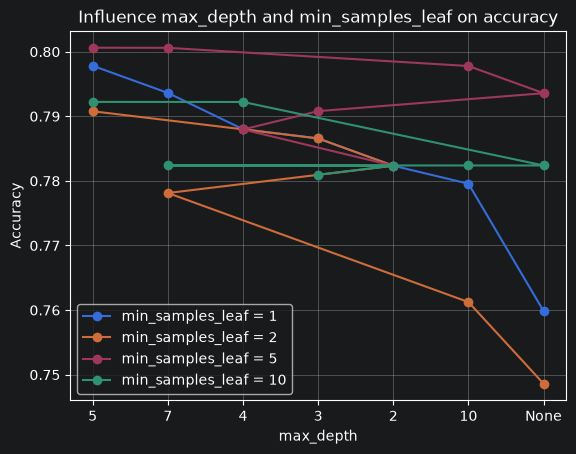

In [80]:
#zanim sprawdzenie modelu na danych testowych, zrobię wizualizację
results_visually = results[[#porządkuję dane
        'param_max_depth',
        'param_min_samples_leaf',
        'mean_test_accuracy',
        'std_test_accuracy',
        'mean_test_f1_macro',
        'std_test_f1_macro'
    ]].copy()

#print(results_visually)

#zależność od accuracy
results_visually['max_depth_plot'] = results_visually['param_max_depth'].fillna('None').astype(str)#aby nie było problemów z NaN
import matplotlib.pyplot as plt
for leaf in [1, 2, 5, 10]:
    data = results_visually[results_visually['param_min_samples_leaf'] == leaf]
    plt.plot(
        data['max_depth_plot'].astype(str),
        data['mean_test_accuracy'],
        marker='o',
        label=f'min_samples_leaf = {leaf}'
    )
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Influence max_depth and min_samples_leaf on accuracy')
plt.legend()
plt.grid()
plt.show()

Widać wyraźnie, że wartości największe max_depth są najkorzystniejsze (oprócz 10), a najwyżej znajduje się kolor odpowiadający 5 min_samples_leaf.

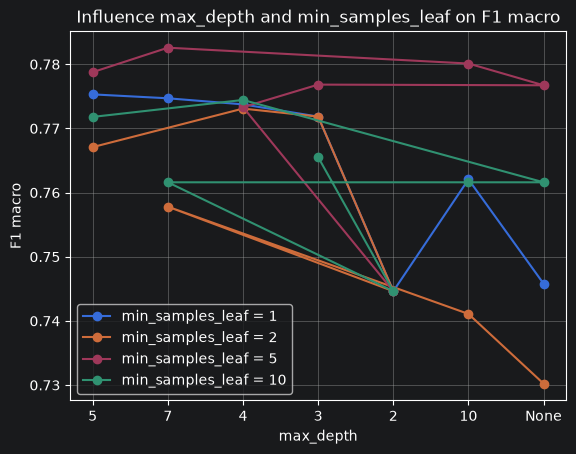

In [81]:
#teraz dla f1 macro
for leaf in [1, 2, 5, 10]:
    data = results_visually[results_visually['param_min_samples_leaf'] == leaf]
    plt.plot(
        data['max_depth_plot'],
        data['mean_test_f1_macro'],
        marker='o',
        label=f'min_samples_leaf = {leaf}'
    )

plt.xlabel('max_depth')
plt.ylabel('F1 macro')
plt.title('Influence max_depth and min_samples_leaf on F1 macro')
plt.legend()
plt.grid()
plt.show()

Ponownie góruje tu kolor różowy. Warto zauważyć, że im niższa wartość max_depth (w tym 10 po drodze), tym F1 macro spada niżej dla większej liczby min_samples_leaf niż w przypadku accuracy.

Wyniki accuracy i f1 macro nie odbiegają od siebie w dużym stopniu. Z wniosków ogólnych, idealnie na tych przykładach widać under i overfitting. Under - kiedy głębokość drzewa jest mała, bo model, mimo dostarczenia mu wielu cech, jest ograniczony. Dla max_depth=10 model został przeuczony i gorzej generalizował. Dla min_samples_leaf również najlepiej sprawdza się wartość nienajwiększa jak i nienajmniejsza. Nie można przesadzić ani z ograniczeniem modelu, ani ze zbytnią generalizacją.

Pora na finalny test naszego pierwszego modelu.

In [82]:
y_pred_tree = best_tree.predict(x_test)

accuracy_test = accuracy_score(
    y_test,
    y_pred_tree
)

f1_macro_test = f1_score(
    y_test,
    y_pred_tree,
    average='macro'
)
print("\nWYNIKI NA DANYCH TESTOWYCH\n")

print("Accuracy:", accuracy_test)
print("F1 macro:", f1_macro_test)
print("\nRaport:")
print(classification_report(y_test, y_pred_tree))


WYNIKI NA DANYCH TESTOWYCH

Accuracy: 0.776536312849162
F1 macro: 0.7492997198879552

Raport:
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       110
           1       0.78      0.58      0.67        69

    accuracy                           0.78       179
   macro avg       0.78      0.74      0.75       179
weighted avg       0.78      0.78      0.77       179



Wyniki są obiecujące, a accuracy nie jest wcale zakłamana, patrząc na metrykę drugą. Zanim wizualizacje, przejdżmy do drugiego modelu, czyli KNN. Zanim trenowanie modelu, muszę przeskalować dane, ponieważ tutaj liczy się odległość między "punktami".

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#uczę skaler tylko na danych treningowych, i użyję go także dla danych testowych, żeby uniknąć data leakage
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) #warto zaznaczyć, że niektóre dane są binarne, a niektóre nie co może mieć pewnie mały wpływ na wyniki.

Metryki pozostają te same, jednak hiperparametry, które zbadam w celu ich optymalnego dobrania to liczba sprawdzanych sąsiadów (najbardziej podstawowy i wpływowy parametr) oraz metric, czyli sprawdzę jak różne, a może podobne wyjdą wyniki, kiedy zastosuje się metrykę euklidesową a jakie, kiedy kosinusową.

In [84]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(weights='distance') #wolę, aby odległość była znacząca

hparam_grid = {
    'n_neighbors': [1, 2, 3, 5, 7, 10, 15, 20, 25, 30],
    'metric': ['euclidean', 'cosine']
}

grid_search_knn = GridSearchCV(
    knn,
    hparam_grid,
    cv=5,
    scoring={
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro'
    },
    refit='accuracy',
    return_train_score=True
)

grid_search_knn.fit(x_train_scaled, y_train)

print("Najlepsze hiperparametry:")
print(grid_search_knn.best_params_)

print("\nNajlepszy wynik accuracy w kroswalidacji:")
print(grid_search_knn.best_score_)

results_knn = pd.DataFrame(grid_search_knn.cv_results_)

results_knn = results_knn[
    [
        'param_n_neighbors',
        'param_metric',
        'mean_train_accuracy',
        'mean_test_accuracy',
        'std_test_accuracy',
        'mean_train_f1_macro',
        'mean_test_f1_macro',
        'std_test_f1_macro'
    ]
]

results_knn = results_knn.sort_values(
    'mean_test_accuracy',
    ascending=False
)

#print(results_knn)

Najlepsze hiperparametry:
{'metric': 'euclidean', 'n_neighbors': 20}

Najlepszy wynik accuracy w kroswalidacji:
0.7879641485275288


Wizualizacje:

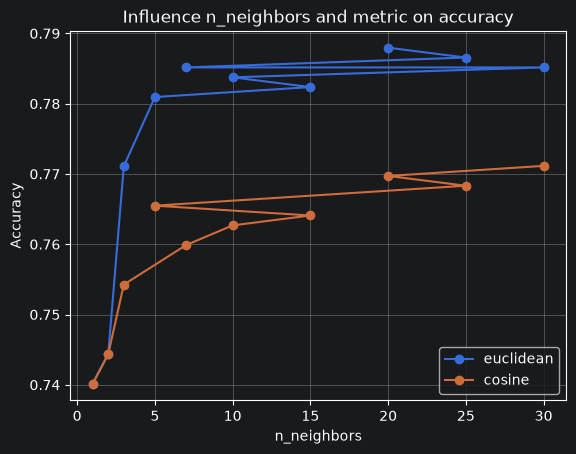

In [85]:
for metric in ['euclidean', 'cosine']:

    data = results_knn[results_knn['param_metric'] == metric]

    plt.plot(
        data['param_n_neighbors'],
        data['mean_test_accuracy'],
        marker='o',
        label=metric
    )

plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title('Influence n_neighbors and metric on accuracy')
plt.legend()
plt.grid()

Widać zdecydowaną dominację metryki euklidesowej. Poza tym, im więcej sprawdzanych sąsiadów, tym lepiej. (Chociaż różnice przy ostatnich wartościach nie są aż tak duże, jak przy mniejszych, czyli nasz max to dobrze dobrana wartość).

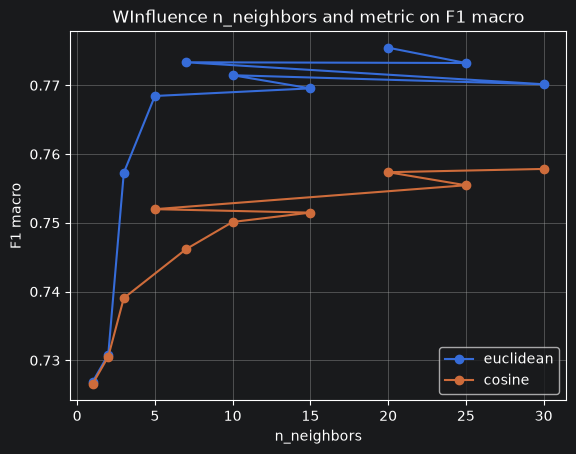

In [86]:
for metric in ['euclidean', 'cosine']:

    data = results_knn[
        results_knn['param_metric'] == metric
    ]

    plt.plot(
        data['param_n_neighbors'],
        data['mean_test_f1_macro'],
        marker='o',
        label=metric
    )

plt.xlabel('n_neighbors')
plt.ylabel('F1 macro')
plt.title('WInfluence n_neighbors and metric on F1 macro')
plt.legend()
plt.grid()
plt.show()

Tutaj różnica nie jest aż tak znacząca, choć nadal jest. To potwierdzenie, że metryka euklidesowa jest lepsza. Jeśli chodzi o liczbę sąsiadów, tendencje są podobne, jak przy accuracy, choć uwidaczniają się nieco wcześniej. Myślę, że odległość euklidesowa okazała się lepsza ze względu na dobre wychwytywanie podobieństwa. Kosinusowa skupia się na kierunku, a dla moich danych te podobieństwa odgrywają większą rolę.

Testujmy!

In [87]:
knn_best = grid_search_knn.best_estimator_
y_pred_knn = knn_best.predict(x_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='macro')

print("\nWYNIKI NA DANYCH TESTOWYCH\n")
print("Accuracy:", accuracy_knn)
print("F1 macro:", f1_knn)

print("\nRaport:")
print(classification_report(y_test, y_pred_knn))



WYNIKI NA DANYCH TESTOWYCH

Accuracy: 0.7597765363128491
F1 macro: 0.748439389482629

Raport:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       110
           1       0.68      0.71      0.70        69

    accuracy                           0.76       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179



Pora na wizualizację i wnioski.

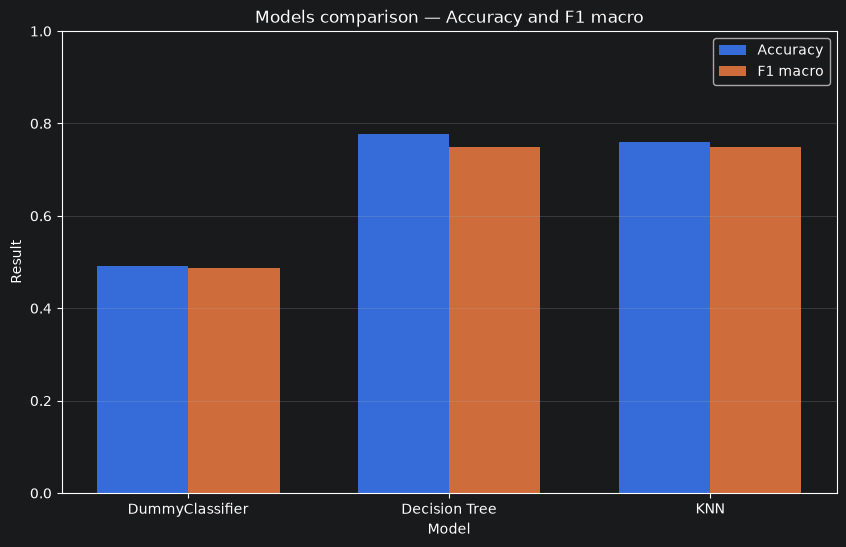

In [88]:
models = ['DummyClassifier', 'Decision Tree', 'KNN']

accuracy = [accuracy_dummy, accuracy_test, accuracy_knn] #kolejno dummy, tree, knn

f1_macro = [f1_dummy, f1_macro_test, f1_knn]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    accuracy,
    width,
    label='Accuracy'
)

plt.bar(
    x + width/2,
    f1_macro,
    width,
    label='F1 macro'
)

plt.xlabel('Model')
plt.ylabel('Result')
plt.title('Models comparison — Accuracy and F1 macro')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

Podsumowując, moje modele, poradziły sobie bardzo dobrze z predykcją przeżywalności. Okolice 80% accuracy oraz f1 macro to zdecydowanie lepszy wynik niż 50% w przypadku losowania klasyfikacji (dummy). Zbliżone wyniki obu metryk potwierdzają, że nie tylko ogół przyporządkowań był dobry, ale także osobno, dla każdej z klas, modele radziły sobie nieźle. Oczywiście gdybym jeszcze lepiej przygotował dane (np zastosował się do wszystkich uwag po reviewsach zadania pierwszego), to wyniki byłyby jeszcze lepsze. Pytanie jeszcze, dlaczego model pierwszy poradził sobie lepiej niż drugi? Być może nie ma dobrego wytłumaczenia, ale być może, dlatego że KNN zbyt mocno przywiązało się do danych treningowych (słabsza generalizacja) albo dlatego że drzewo decyzyjne bardziej bazuje na powiązaniach cech niż na podobieństwie pasażerów, co nawet intuicyjnie ma więcej sensu, a przecież w analizie danych wyszło wiele zależności między cechami.